In [1]:
#graph visualization.

In [7]:
import sys
sys.path.insert(0, '/home/bernardop/Hie_Ta_Summ/HieTaSumm-0.1.48')
from HieTaSumm import HieTaSumm
HieTaSumm(
        #features_path='/home/bernardop/Hie_Ta_Summ/HieTaSumm-0.1.48/HieTaSumm/features_directory',
        features_path='/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/para_print',
        percent=15,
        rate=30,
        time=4,
        alpha=100,
        selected_model='resnet50',
        summary_path='/home/bernardop/skim-8-vgg',
        gen_summary_method={"method": "group_central_frames"},#'group_sparse_central_features'},
        hierarchy="watershed_hierarchy_by_area"
    )

DEBUG: Graph content is empty. Calling load_features...
DEBUG: bestcutnumber: 1.0
[(0, 1, 1.0), (0, 2, 1.0), (0, 3, 1.0), (0, 4, 1.0), (0, 5, 1.0), (0, 6, 1.0), (0, 7, 34.0), (0, 8, 38.0), (0, 9, 46.0), (0, 10, 41.0), (0, 11, 39.0), (0, 12, 38.0), (0, 13, 38.0), (0, 14, 37.0), (0, 15, 36.0), (0, 16, 35.0), (0, 17, 36.0), (0, 18, 37.0), (0, 19, 36.0), (0, 20, 36.0)]
DEBUG: Initial len_shot: 17
DEBUG: Initial cut_number: 3
DEBUG: Number of connected subgraphs: 4
DEBUG: self.len_shot before division: 17
DEBUG: self.len_shot after division: 10
DEBUG: Subgraph 0 node count: 173
DEBUG: Subgraph 0 leaf list count: 87
DEBUG: Keyshot range: 38 to 48
DEBUG: Subgraph 1 node count: 37
DEBUG: Subgraph 1 leaf list count: 19
DEBUG: Keyshot range: 4 to 14
DEBUG: Subgraph 2 node count: 11
DEBUG: Subgraph 2 leaf list count: 6
DEBUG: Keyshot range: 0 to 6
DEBUG: Subgraph 3 node count: 13
DEBUG: Subgraph 3 leaf list count: 7
DEBUG: Keyshot range: 0 to 7
----------------------
The avg fscore of all videos 

/home/bernardop/Hie_ta_Summ_venv/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/home/bernardop/Hie_ta_Summ_venv/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 119 samples in 0.000s...
[t-SNE] Computed neighbors for 119 samples in 0.005s...
[t-SNE] Computed conditional probabilities for sample 119 / 119
[t-SNE] Mean sigma: 1.655499
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.697388
[t-SNE] KL divergence after 1000 iterations: 0.310640


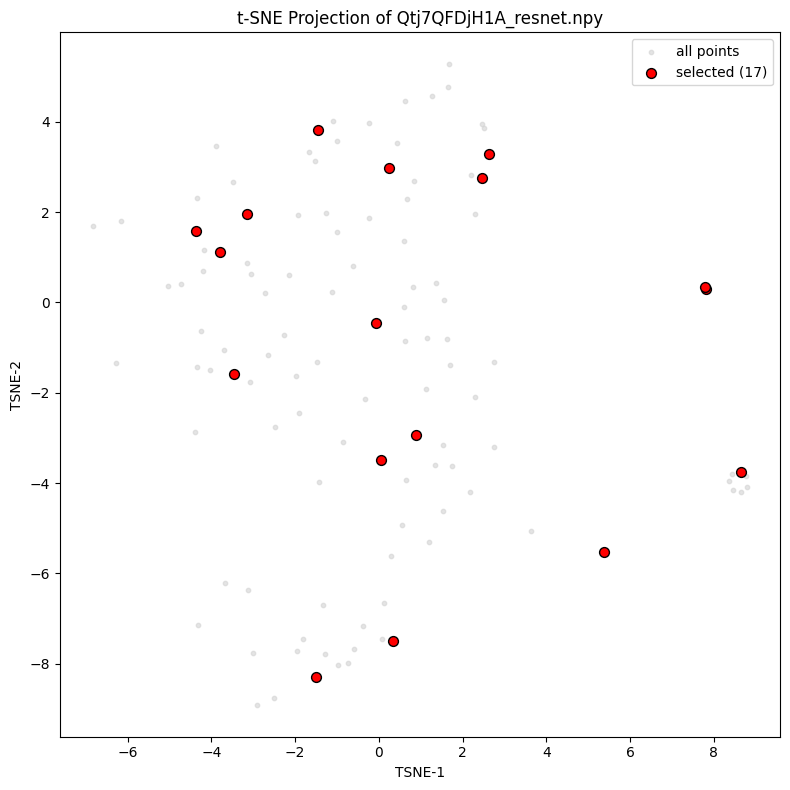

In [1]:
# Jupyter Cell: t-SNE Plot with Highlighted Selections

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Hardcoded file paths
npy_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/para_print/Qtj7QFDjH1A_resnet.npy"
idx_txt_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/trainvalindexes_print/Qtj7QFDjH1A_resnet.txt"

# 1. Load data
X = np.load(npy_path)  # Expect shape: (n_samples, 2048)
assert X.ndim == 2, "Expected a 2D array"

# 2. Load selected indices
selected = np.loadtxt(idx_txt_path, dtype=int)
selected = np.unique(selected)
n_samples = X.shape[0]
if np.any(selected < 0) or np.any(selected >= n_samples):
    raise ValueError(f"indices out of bounds [0, {n_samples}): {selected}")

# 3. Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    random_state=0,
    n_iter=1000,
    verbose=1
)
X2 = tsne.fit_transform(X)

# 4. Plot inline
plt.figure(figsize=(8, 8))
# Plot all points in light gray
plt.scatter(X2[:, 0], X2[:, 1],
            s=10, c='lightgray', alpha=0.6, label='all points')
# Highlight selected points in red
plt.scatter(X2[selected, 0], X2[selected, 1],
            s=50, c='red', edgecolor='k',
            label=f'selected ({len(selected)})')

plt.title("t-SNE Projection of Qtj7QFDjH1A_resnet.npy")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend(loc='best')
plt.tight_layout()
plt.show()


/home/bernardop/Hie_ta_Summ_venv/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/home/bernardop/Hie_ta_Summ_venv/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 119 samples in 0.000s...
[t-SNE] Computed neighbors for 119 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 119 / 119
[t-SNE] Mean sigma: 1.655499
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.697380
[t-SNE] KL divergence after 1000 iterations: 0.310640


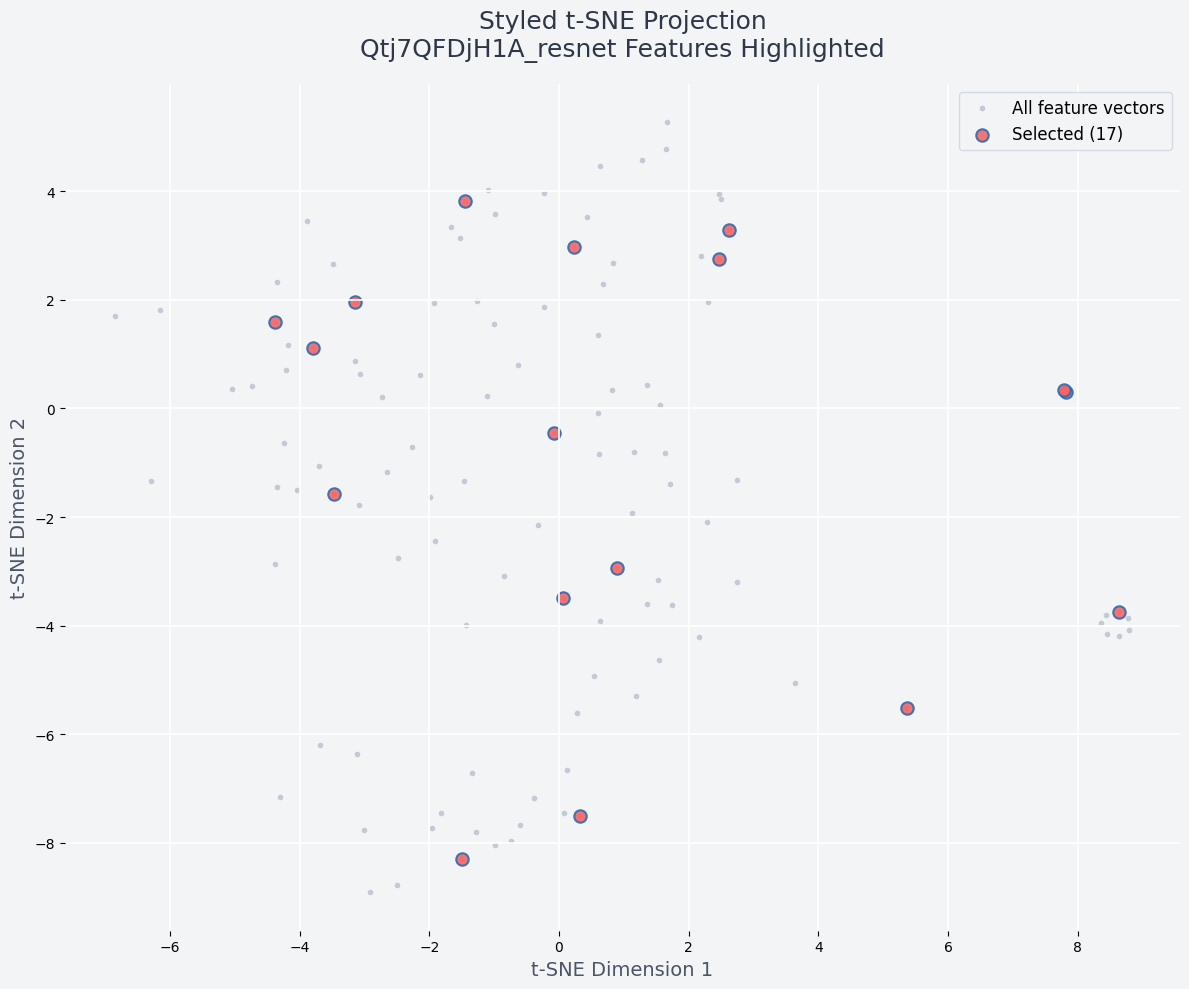

In [4]:
# Jupyter Cell: Styled t-SNE Plot with Highlighted Selections

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Hardcoded file paths
npy_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/para_print/Qtj7QFDjH1A_resnet.npy"
idx_txt_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/trainvalindexes_print/Qtj7QFDjH1A_resnet.txt"

# Load data
X = np.load(npy_path)
selected = np.loadtxt(idx_txt_path, dtype=int)
selected = np.unique(selected)
n_samples = X.shape[0]
if np.any(selected < 0) or np.any(selected >= n_samples):
    raise ValueError(f"indices out of bounds [0, {n_samples}): {selected}")

# Compute t-SNE embedding
tsne = TSNE(n_components=2, perplexity=30, init='pca',
            random_state=0, n_iter=1000, verbose=1)
X2 = tsne.fit_transform(X)

# Begin styled plot
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#F3F4F6')
ax.set_facecolor('#F3F4F6')

# Plot all points
ax.scatter(
    X2[:, 0], X2[:, 1],
    s=20, linewidth=0.5, edgecolor='white',
    facecolor='#A0AEC0', alpha=0.6, label='All feature vectors'
)

# Highlight selected points
ax.scatter(
    X2[selected, 0], X2[selected, 1],
    s=80, linewidth=1.5, edgecolor='#2B6CB0',
    facecolor='#F56565', alpha=0.9, label=f'Selected ({len(selected)})'
)

# Grid and spines
ax.grid(color='white', linewidth=1.2)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend styling
legend = ax.legend(
    loc='upper right',
    frameon=True,
    framealpha=0.8,
    edgecolor='#CBD5E0',
    fontsize=12
)
legend.get_frame().set_facecolor('#F3F4F6')

# Titles and labels
ax.set_title(
    "Styled t-SNE Projection\nQtj7QFDjH1A_resnet Features Highlighted",
    fontsize=18, color='#2D3748', pad=20
)
ax.set_xlabel("t-SNE Dimension 1", fontsize=14, color='#4A5568')
ax.set_ylabel("t-SNE Dimension 2", fontsize=14, color='#4A5568')

# Tight layout
plt.tight_layout()
plt.show()


/home/bernardop/Hie_ta_Summ_venv/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/home/bernardop/Hie_ta_Summ_venv/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 483 samples in 0.001s...
[t-SNE] Computed neighbors for 483 samples in 0.015s...
[t-SNE] Computed conditional probabilities for sample 483 / 483
[t-SNE] Mean sigma: 1.622361
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.559555
[t-SNE] KL divergence after 1000 iterations: 0.831410


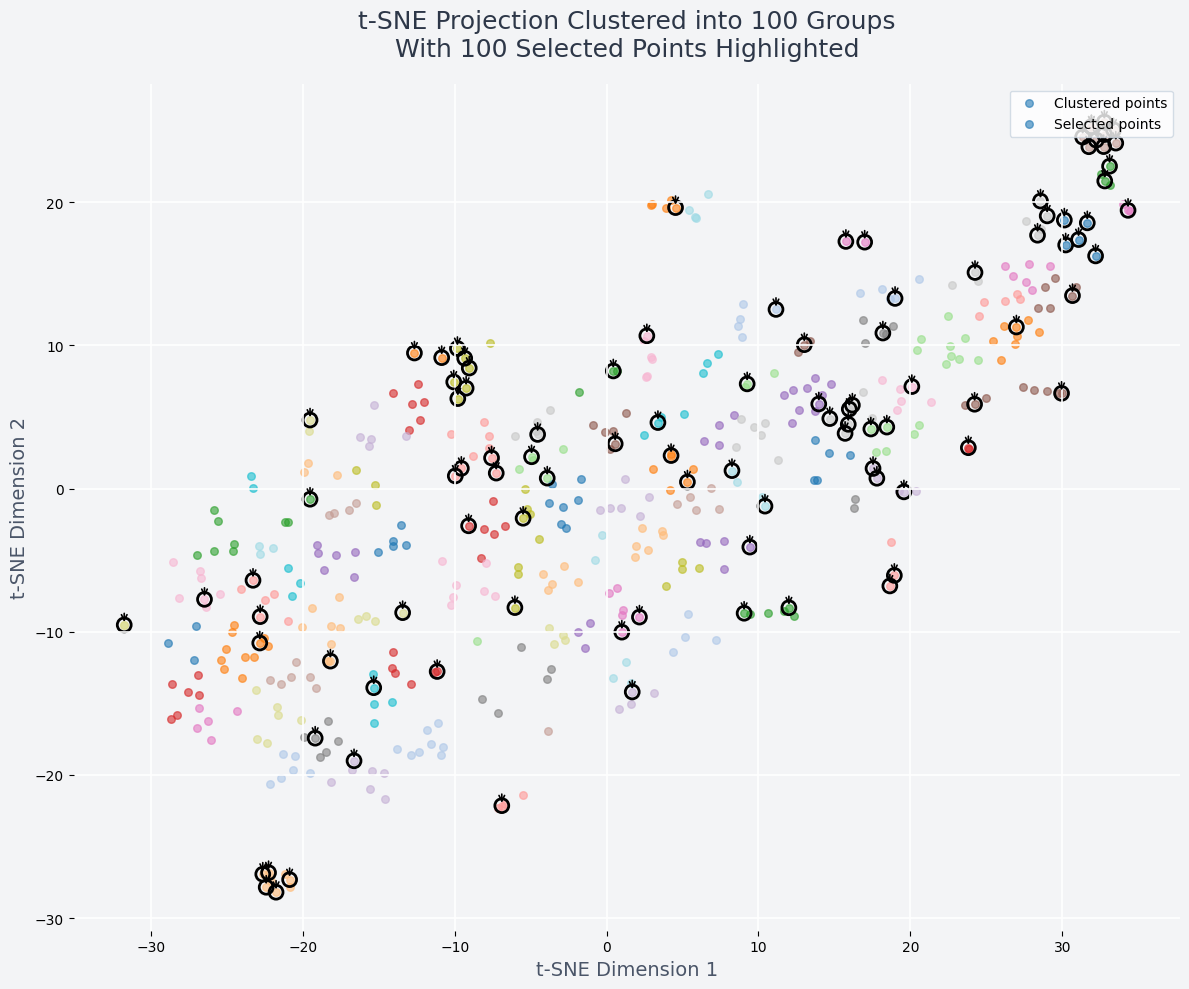

In [3]:
# Jupyter Cell: Clustered t-SNE with Highlighted Selections and Arrows

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# Hardcoded file paths
#npy_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/trainvalTESTE_1000/0T1FKHx3yOk_resnet.npy"
#idx_txt_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/trainvalindexes1000/0T1FKHx3yOk_resnet.txt"

npy_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/trainval_100_random/_4CLYKFzmoY_resnet.npy"
idx_txt_path = "/home/bernardop/recurrent-transformer/video_feature/rt_anet_feat/trainvalindexes_100_random/_4CLYKFzmoY_resnet.txt"


#1ErQKcUju8o_bn

# Load data
X = np.load(npy_path)
selected = np.loadtxt(idx_txt_path, dtype=int)
selected = np.unique(selected)
n_samples = X.shape[0]
if np.any(selected < 0) or np.any(selected >= n_samples):
    raise ValueError(f"indices out of bounds [0, {n_samples}): {selected}")

# Compute t-SNE embedding
tsne = TSNE(n_components=2, perplexity=30, init='pca',
            random_state=0, n_iter=1000, verbose=1)
X2 = tsne.fit_transform(X)

# Clustering into #clusters = number of selected points
n_clusters = len(selected)
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
cluster_labels = kmeans.fit_predict(X2)

# Plotting
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#F3F4F6')
ax.set_facecolor('#F3F4F6')

# Scatter all points colored by cluster
cmap = plt.cm.get_cmap('tab20', n_clusters)
for cluster in range(n_clusters):
    mask = (cluster_labels == cluster)
    ax.scatter(
        X2[mask, 0], X2[mask, 1],
        s=30, color=cmap(cluster),
        alpha=0.6, label=f'Cluster {cluster+1}' if cluster < 10 else None
    )

# Highlight selected points
ax.scatter(
    X2[selected, 0], X2[selected, 1],
    s=100, facecolor='none', edgecolor='black',
    linewidth=2.0, label='Selected points'
)

# Add arrows pointing to selected points
for idx in selected:
    x, y = X2[idx]
    ax.annotate(
        '', xy=(x, y), xytext=(x, y + 1.0),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.2)
    )

# Remove spines, add grid
ax.grid(color='white', linewidth=1.2)
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend (show only selected in legend for clarity)
ax.legend(
    ['Clustered points', 'Selected points'],
    loc='upper right',
    frameon=True, framealpha=0.8, edgecolor='#CBD5E0'
)

# Titles and labels
ax.set_title(
    f"t-SNE Projection Clustered into {n_clusters} Groups\nWith {n_clusters} Selected Points Highlighted",
    fontsize=18, color='#2D3748', pad=20
)
ax.set_xlabel("t-SNE Dimension 1", fontsize=14, color='#4A5568')
ax.set_ylabel("t-SNE Dimension 2", fontsize=14, color='#4A5568')

plt.tight_layout()
plt.show()
